In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv(
    "Superstore.csv",
    encoding='latin1'
)

print(df.shape)

df.head()

(9120, 21)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [ ]:
df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    dayfirst=True,
    errors='coerce'
)

In [ ]:
df['Month'] = df['Order Date'].dt.month

df['Quarter'] = df['Order Date'].dt.quarter

In [ ]:
df_new = df.copy()

In [ ]:
Q1 = df_new['Sales'].quantile(0.25)

Q3 = df_new['Sales'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df_new = df_new[
    (df_new['Sales'] >= lower) &
    (df_new['Sales'] <= upper)
]

print(df_new.shape)

(8052, 23)


Exploratory Data Analysis (EDA)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

1. Sales by Category


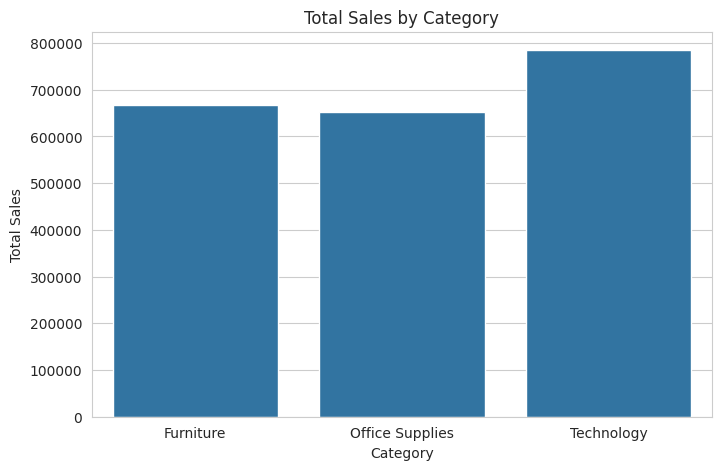

In [ ]:
plt.figure(figsize=(8,5))

category_sales = df.groupby('Category')['Sales'].sum()

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

2. Sales by Region

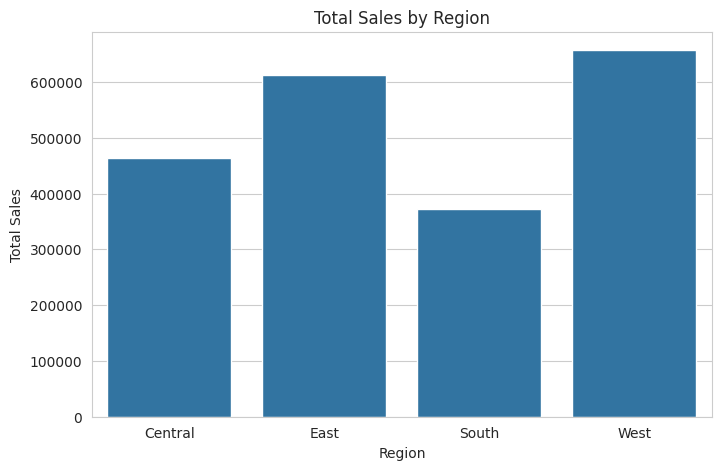

In [ ]:
plt.figure(figsize=(8,5))

region_sales = df.groupby('Region')['Sales'].sum()

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")

plt.show()

3. Monthly Sales Trend

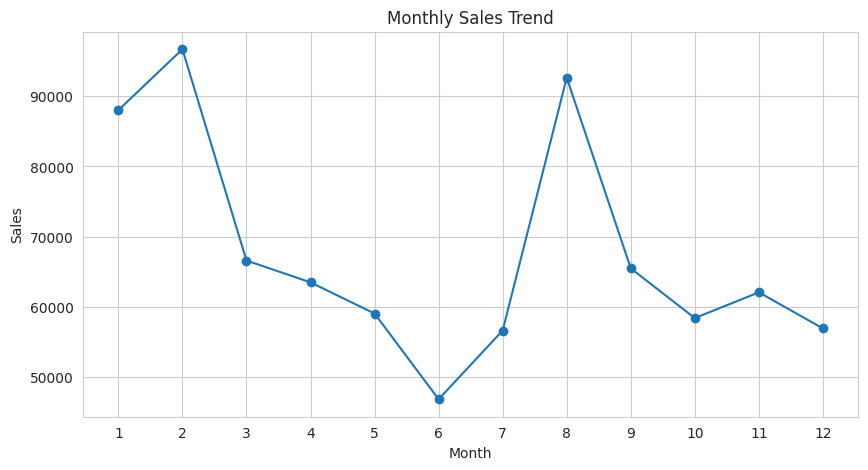

In [ ]:
# Create Month column if not created
df['Month'] = df['Order Date'].dt.month

monthly_sales = df.groupby('Month')['Sales'].sum()

plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker='o'
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.xticks(range(1,13))

plt.show()

4. Profit Analysis

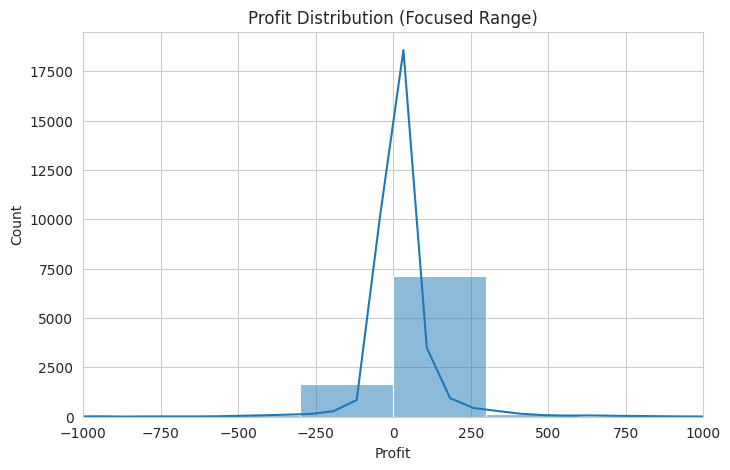

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Profit'],
    bins=50,
    kde=True
)

plt.xlim(-1000, 1000)

plt.title("Profit Distribution (Focused Range)")
plt.xlabel("Profit")

plt.show()

5. Discount vs Sales

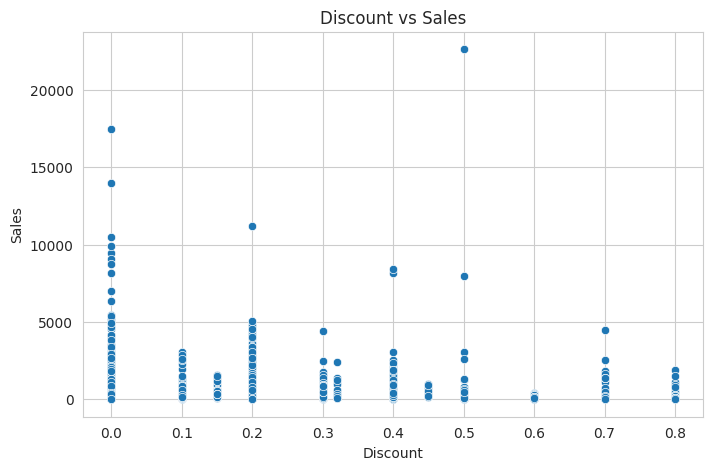

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['Discount'],
    y=df['Sales']
)

plt.title("Discount vs Sales")
plt.xlabel("Discount")
plt.ylabel("Sales")

plt.show()

6. Profit by Category

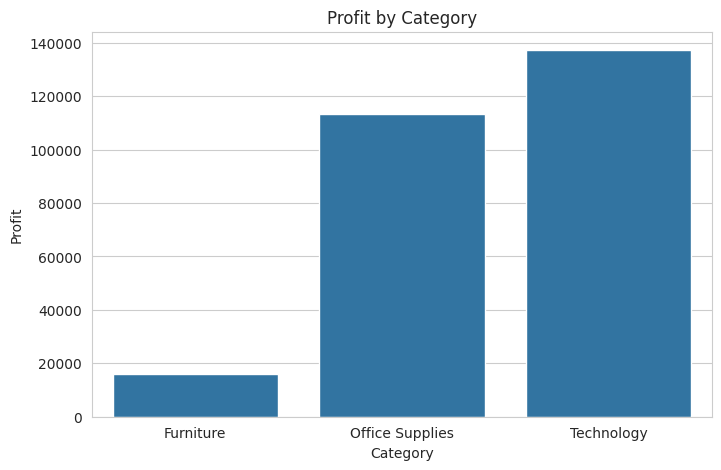

In [ ]:
plt.figure(figsize=(8,5))

category_profit = df.groupby('Category')['Profit'].sum()

sns.barplot(
    x=category_profit.index,
    y=category_profit.values
)

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()

7. Correlation Heatmap

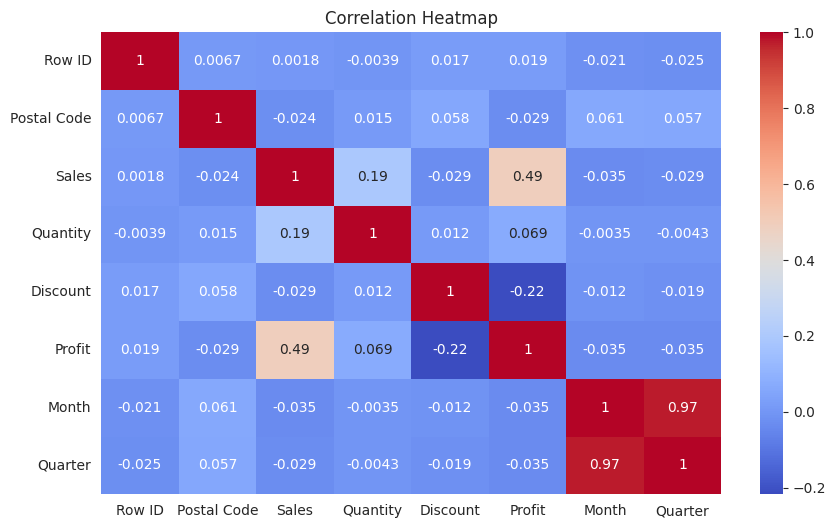

In [ ]:
plt.figure(figsize=(10,6))

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(
    numeric_cols.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

8. Top 10 States by Sales

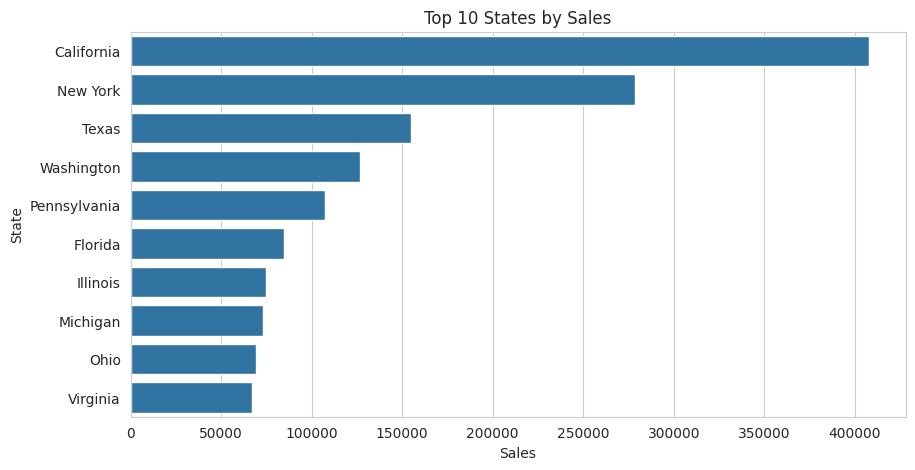

In [ ]:
top_states = (
    df.groupby('State')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,5))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")
plt.xlabel("Sales")
plt.ylabel("State")

plt.show()

9. Sales Distribution

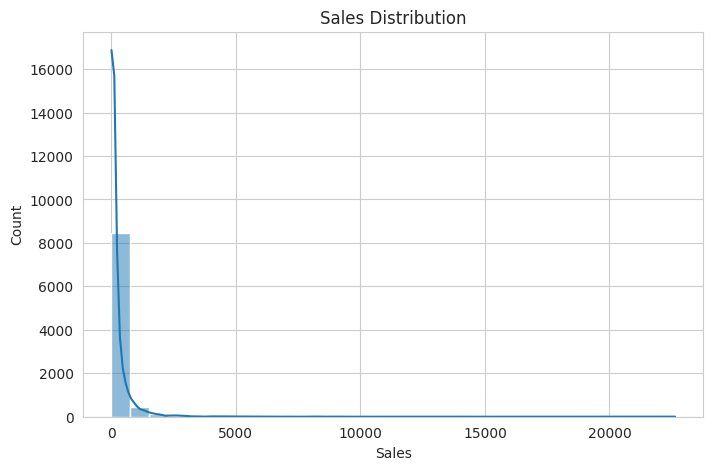

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Sales'],
    bins=30,
    kde=True
)

plt.title("Sales Distribution")
plt.xlabel("Sales")

plt.show()

10. Boxplot for Outlier Detection

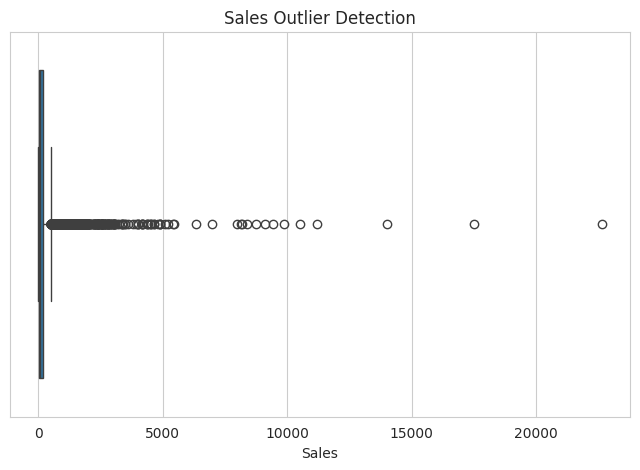

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['Sales']
)

plt.title("Sales Outlier Detection")

plt.show()

In [ ]:
df_ml_new = df_new[
[
    'Category',
    'Sub-Category',
    'Region',
    'State',
    'Segment',
    'Ship Mode',
    'Discount',
    'Quantity',
    'Month',
    'Quarter',
    'Profit',
    'Sales'
]
]

In [ ]:
df_ml_encoded_new = pd.get_dummies(df_ml_new)

print(df_ml_encoded_new.shape)

df_ml_encoded_new.head()

(8052, 85)


,Discount,Quantity,Month,Quarter,Profit,Sales,Category_Furniture,Category_Office Supplies,Category_Technology,Sub-Category_Accessories,...,State_Washington,State_West Virginia,State_Wisconsin,Segment_Consumer,Segment_Corporate,Segment_Home Office,Ship Mode_First Class,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,0.0,2.0,8.0,3.0,41.9136,261.960,True,False,False,False,...,False,False,False,True,False,False,False,False,True,False
2,0.0,2.0,12.0,4.0,6.8714,14.620,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
4,0.2,2.0,11.0,4.0,2.5164,22.368,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True
5,0.0,7.0,9.0,3.0,14.1694,48.860,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
6,0.0,4.0,9.0,3.0,1.9656,7.280,False,True,False,False,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
X = df_ml_encoded_new.drop('Sales', axis=1)

y = np.log1p(df_ml_encoded_new['Sales'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=300, random_state=42)

In [ ]:
y_pred_log = model.predict(X_test)

y_pred = np.expm1(y_pred_log)

y_test_actual = np.expm1(y_test)

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

import numpy as np

print("R2 Score:", r2_score(y_test_actual, y_pred))

print("MAE:", mean_absolute_error(y_test_actual, y_pred))

print("RMSE:", np.sqrt(
    mean_squared_error(y_test_actual, y_pred)
))

R2 Score: 0.8071660030606994
MAE: 22.363224319573643
RMSE: 50.3961497620067


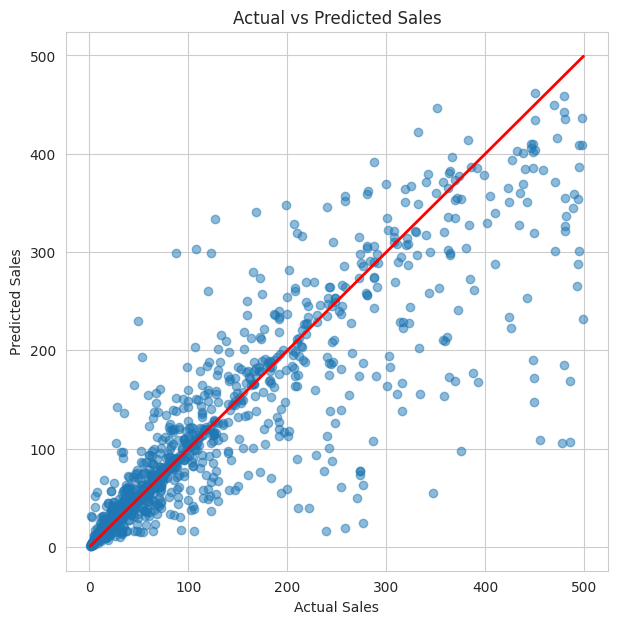

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,7))

plt.scatter(
    y_test_actual,
    y_pred,
    alpha=0.5
)

plt.plot(
    [y_test_actual.min(), y_test_actual.max()],
    [y_test_actual.min(), y_test_actual.max()],
    color='red',
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")

plt.title("Actual vs Predicted Sales")

plt.show()

In [ ]:
df_ml_encoded_new = df_ml_encoded_new.dropna()

In [ ]:
X = df_ml_encoded_new.drop('Sales', axis=1)

y = np.log1p(df_ml_encoded_new['Sales'])

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred_lr_log = lr_model.predict(X_test)

y_pred_lr = np.expm1(y_pred_lr_log)

In [ ]:
y_test_actual = np.expm1(y_test)

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("Linear Regression Results")

print("R2 Score:",
      r2_score(y_test_actual, y_pred_lr))

print("MAE:",
      mean_absolute_error(y_test_actual, y_pred_lr))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test_actual,
              y_pred_lr
          )
      ))

Linear Regression Results
R2 Score: 0.3398055706444606
MAE: 54.9154618290539
RMSE: 94.49013305230464


In [ ]:
!pip install xgboost

In [ ]:
from xgboost import XGBRegressor

In [ ]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

In [ ]:
xgb_model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb_log = xgb_model.predict(X_test)

y_pred_xgb = np.expm1(y_pred_xgb_log)

y_test_actual = np.expm1(y_test)

In [ ]:
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error
)

print("XGBoost Results")

print("R2 Score:",
      r2_score(y_test_actual, y_pred_xgb))

print("MAE:",
      mean_absolute_error(y_test_actual, y_pred_xgb))

print("RMSE:",
      np.sqrt(
          mean_squared_error(
              y_test_actual,
              y_pred_xgb
          )
      ))

XGBoost Results
R2 Score: 0.8271955689717981
MAE: 23.256436054548594
RMSE: 48.342373558354396


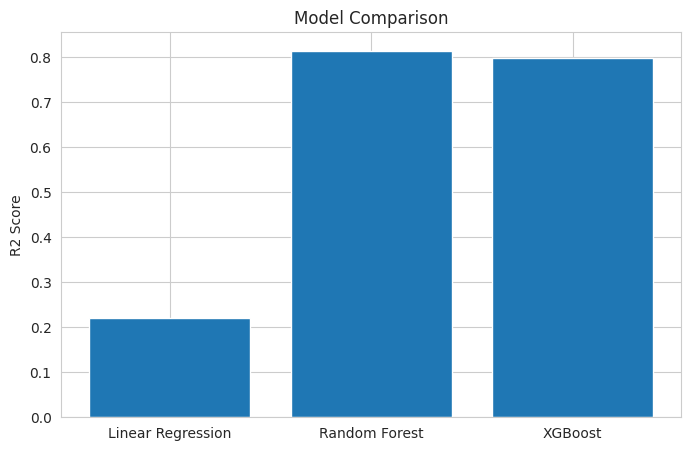

In [ ]:
import matplotlib.pyplot as plt

models = [
    'Linear Regression',
    'Random Forest',
    'XGBoost'
]

r2_scores = [
    0.221,
    0.815,
    0.799
]

plt.figure(figsize=(8,5))

plt.bar(models, r2_scores)

plt.ylabel("R2 Score")

plt.title("Model Comparison")

plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature importance values
importance = model.feature_importances_

# Feature names
feature_names = X.columns

# Create dataframe
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

# Sort values
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

# Display top 10 features
print(feature_importance.head(10))

                     Feature  Importance
4                     Profit    0.678440
6   Category_Office Supplies    0.105852
22      Sub-Category_Storage    0.056103
0                   Discount    0.042023
17  Sub-Category_Furnishings    0.023292
1                   Quantity    0.020496
7        Category_Technology    0.008879
5         Category_Furniture    0.008136
9    Sub-Category_Appliances    0.006577
10          Sub-Category_Art    0.005095


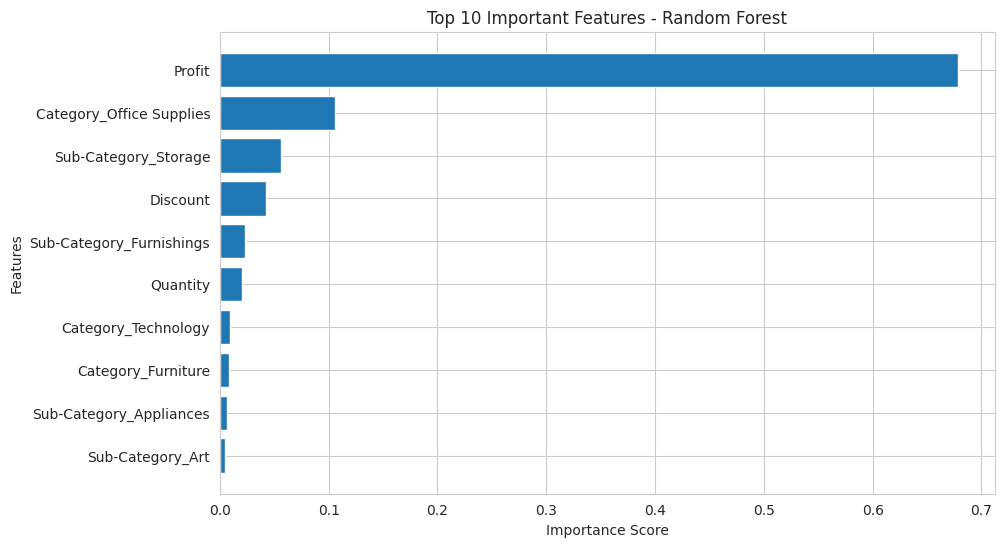

In [ ]:
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.title("Top 10 Important Features - Random Forest")

plt.gca().invert_yaxis()

plt.show()

In [ ]:
df['Category'].unique()

array(['Furniture', 'Office Supplies', 'Technology', nan], dtype=object)

In [ ]:
df['Sub-Category'].unique()

array(['Bookcases', 'Chairs', 'Labels', 'Tables', 'Storage',
       'Furnishings', 'Art', 'Phones', 'Binders', 'Appliances', 'Paper',
       'Accessories', 'Envelopes', 'Fasteners', 'Supplies', 'Machines',
       'Copiers', nan], dtype=object)

In [ ]:
df['Category'].value_counts()

,count
Category,
Office Supplies,5486
Furniture,1935
Technology,1698


In [ ]:
df['Sub-Category'].value_counts()

,count
Sub-Category,
Binders,1384
Paper,1245
Furnishings,870
Phones,815
Storage,779
Art,723
Accessories,708
Chairs,562
Appliances,420


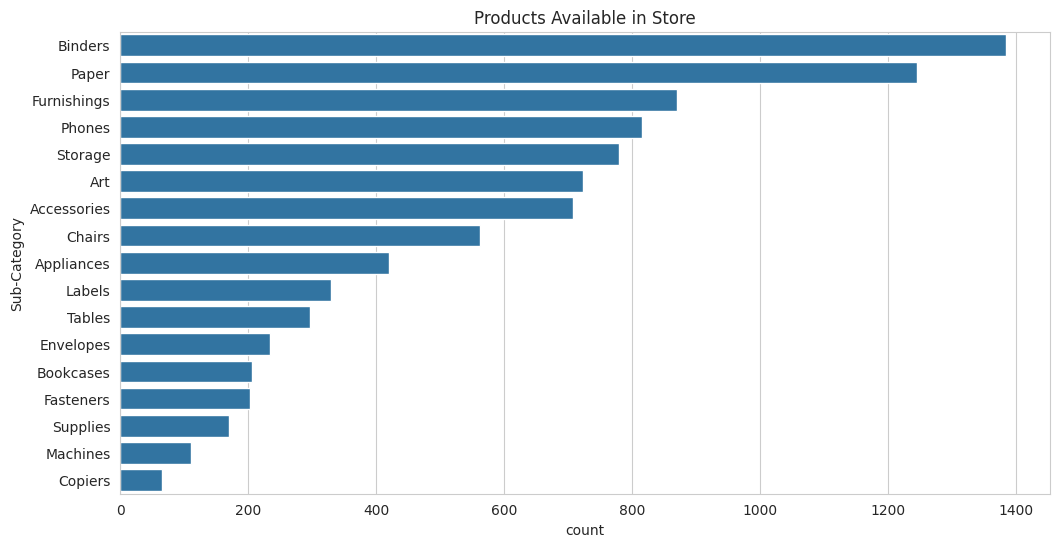

In [ ]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    y='Sub-Category',
    order=df['Sub-Category'].value_counts().index
)

plt.title("Products Available in Store")
plt.show()

Product Performance Analysis

Product Analysis Table

In [ ]:
product_analysis = df.groupby('Sub-Category').agg({
    'Sales':'sum',
    'Profit':'sum',
    'Discount':'mean',
    'Quantity':'sum'
}).sort_values(by='Sales', ascending=False)

product_analysis

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Phones,300089.9980,40333.9183,0.154356,3005.0
Chairs,296104.9010,24293.5408,0.170463,2134.0
Storage,202498.0460,19532.7267,0.073171,2897.0
Tables,190325.5880,-16477.3724,0.263805,1165.0
Machines,183470.9690,2971.7612,0.300909,428.0
Binders,180395.7380,28915.5090,0.372688,5430.0
Accessories,156134.1580,39498.3912,0.076836,2715.0
Copiers,145348.1120,54435.8480,0.156923,223.0
Bookcases,98734.8317,-3779.0076,0.208738,788.0


SORT BY SALES

In [ ]:
product_analysis = product_analysis.sort_values(
    by='Sales',
    ascending=False
)

product_analysis.head(10)

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Phones,300089.9980,40333.9183,0.154356,3005.0
Chairs,296104.9010,24293.5408,0.170463,2134.0
Storage,202498.0460,19532.7267,0.073171,2897.0
Tables,190325.5880,-16477.3724,0.263805,1165.0
Machines,183470.9690,2971.7612,0.300909,428.0
Binders,180395.7380,28915.5090,0.372688,5430.0
Accessories,156134.1580,39498.3912,0.076836,2715.0
Copiers,145348.1120,54435.8480,0.156923,223.0
Bookcases,98734.8317,-3779.0076,0.208738,788.0


SORT BY SALES

In [ ]:
product_analysis = product_analysis.sort_values(
    by='Sales',
    ascending=False
)

product_analysis.head(10)

,Sales,Profit,Discount,Quantity
Sub-Category,,,,
Phones,300089.9980,40333.9183,0.154356,3005.0
Chairs,296104.9010,24293.5408,0.170463,2134.0
Storage,202498.0460,19532.7267,0.073171,2897.0
Tables,190325.5880,-16477.3724,0.263805,1165.0
Machines,183470.9690,2971.7612,0.300909,428.0
Binders,180395.7380,28915.5090,0.372688,5430.0
Accessories,156134.1580,39498.3912,0.076836,2715.0
Copiers,145348.1120,54435.8480,0.156923,223.0
Bookcases,98734.8317,-3779.0076,0.208738,788.0


VISUALIZE TOP PRODUCTS

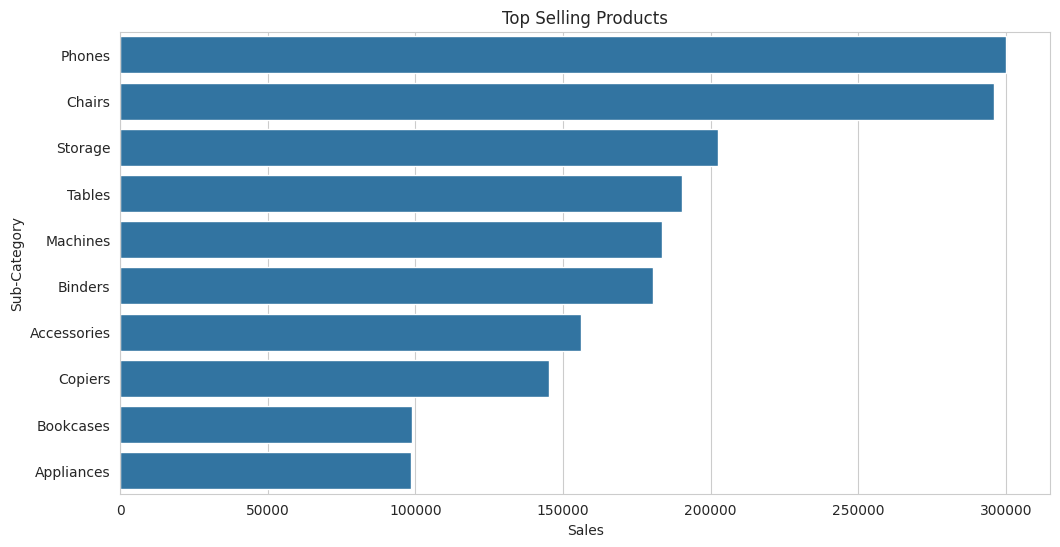

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=product_analysis.head(10),
    x='Sales',
    y='Sub-Category'
)

plt.title("Top Selling Products")
plt.show()

PROFIT ANALYSIS

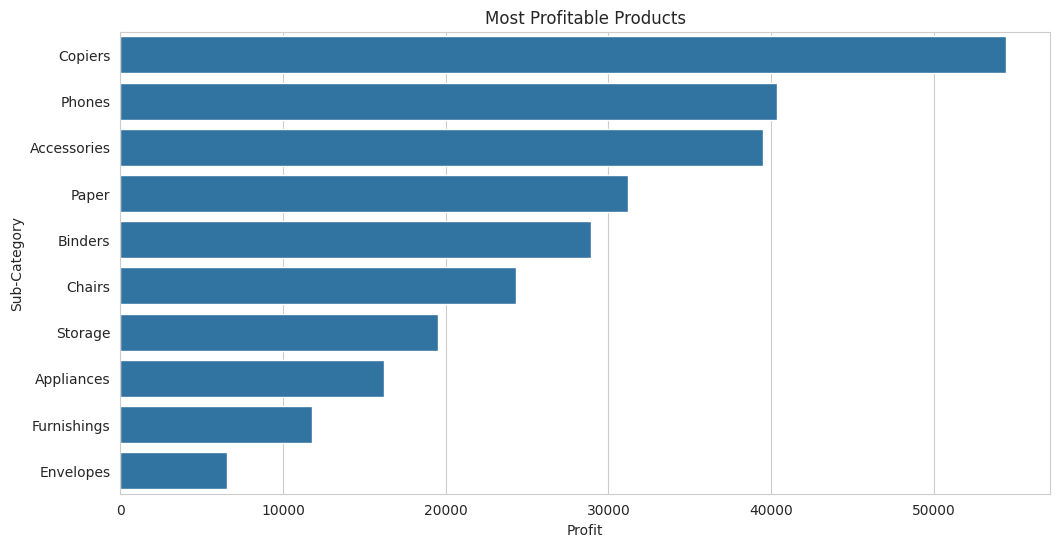

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=product_analysis.sort_values(
        by='Profit',
        ascending=False
    ).head(10),
    x='Profit',
    y='Sub-Category'
)

plt.title("Most Profitable Products")
plt.show()

DISCOUNT ANALYSIS

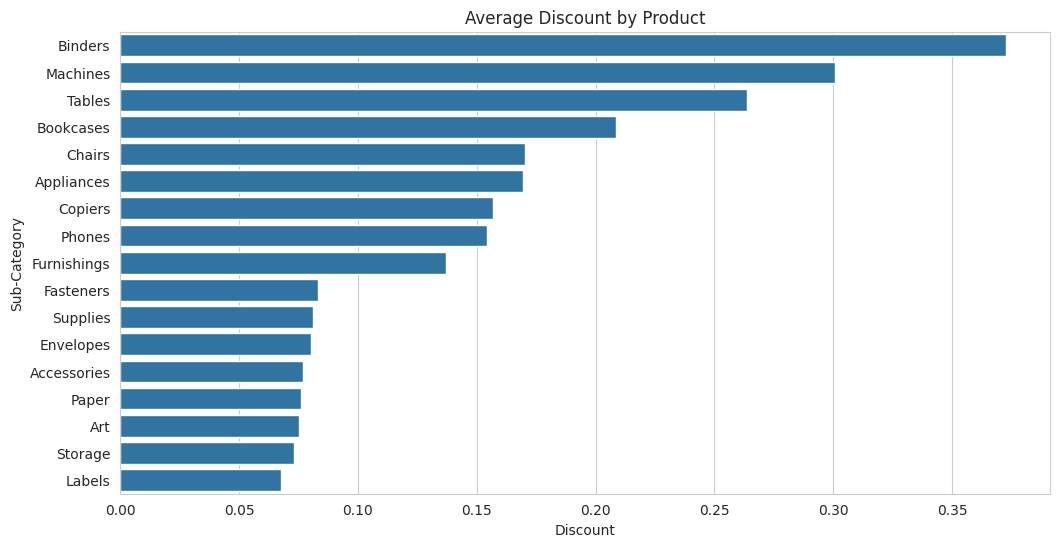

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=product_analysis.sort_values(
        by='Discount',
        ascending=False
    ),
    x='Discount',
    y='Sub-Category'
)

plt.title("Average Discount by Product")
plt.show()

Recommendation Categories

In [ ]:
def recommend_strategy(row):

    if row['Sales'] > 150000 and row['Profit'] > 20000:
        return "Premium Placement & Combo Offers"

    elif row['Profit'] < 0:
        return "Reduce Discounts & Improve Placement"

    elif row['Discount'] > 0.25:
        return "Discount Optimization Needed"

    else:
        return "Regular Promotion"

product_analysis['Recommendation'] = (
    product_analysis.apply(
        recommend_strategy,
        axis=1
    )
)

product_analysis

,Sales,Profit,Discount,Quantity,Recommendation
Sub-Category,,,,,
Phones,300089.9980,40333.9183,0.154356,3005.0,Premium Placement & Combo Offers
Chairs,296104.9010,24293.5408,0.170463,2134.0,Premium Placement & Combo Offers
Storage,202498.0460,19532.7267,0.073171,2897.0,Regular Promotion
Tables,190325.5880,-16477.3724,0.263805,1165.0,Reduce Discounts & Improve Placement
Machines,183470.9690,2971.7612,0.300909,428.0,Discount Optimization Needed
Binders,180395.7380,28915.5090,0.372688,5430.0,Premium Placement & Combo Offers
Accessories,156134.1580,39498.3912,0.076836,2715.0,Premium Placement & Combo Offers
Copiers,145348.1120,54435.8480,0.156923,223.0,Regular Promotion
Bookcases,98734.8317,-3779.0076,0.208738,788.0,Reduce Discounts & Improve Placement


RECOMMENDATION COUNT CHART

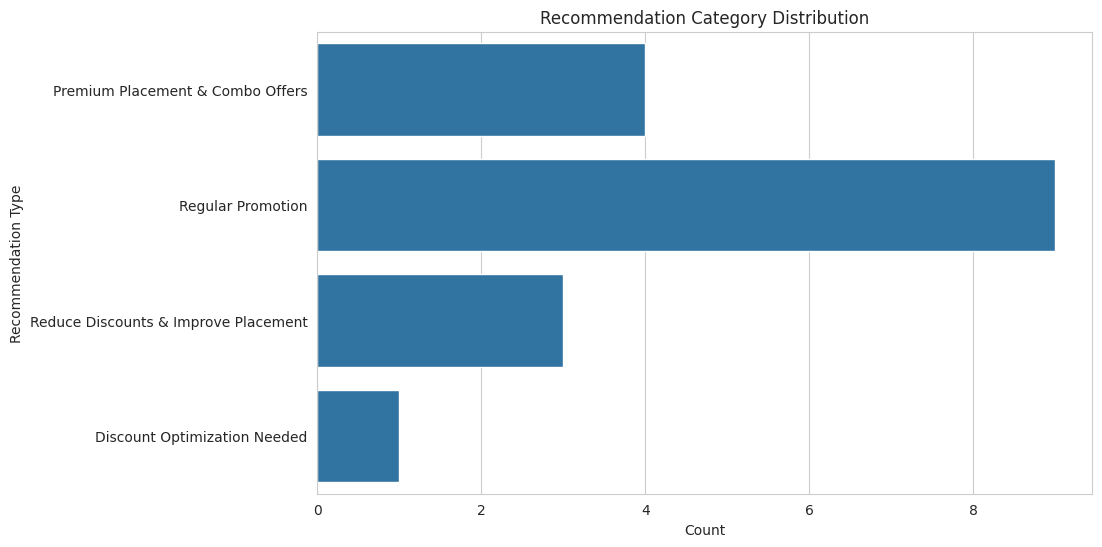

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    y='Recommendation',
    data=product_analysis
)

plt.title("Recommendation Category Distribution")
plt.xlabel("Count")
plt.ylabel("Recommendation Type")

plt.show()

SALES VS PROFIT VISUALIZATION

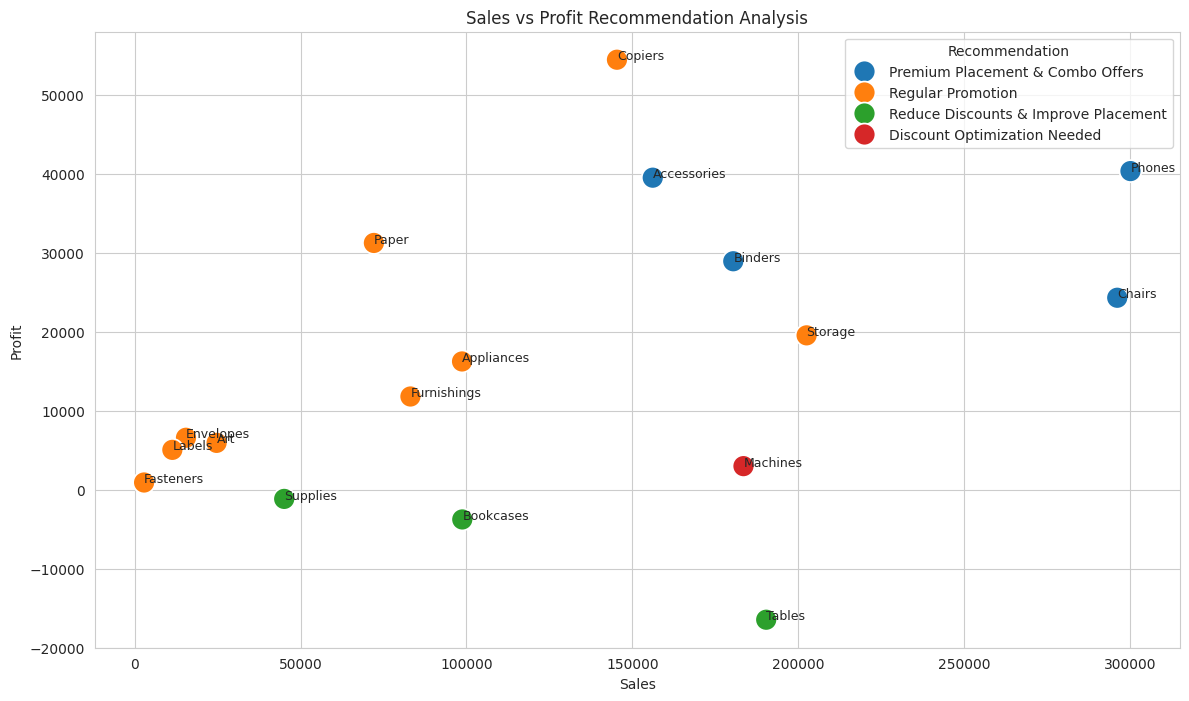

In [ ]:
plt.figure(figsize=(14,8))

sns.scatterplot(
    data=product_analysis,
    x='Sales',
    y='Profit',
    hue='Recommendation',
    s=250
)

# Add product names
for i in range(len(product_analysis)):

    plt.text(
        product_analysis['Sales'].iloc[i],
        product_analysis['Profit'].iloc[i],
        product_analysis.index[i],
        fontsize=9
    )

plt.title("Sales vs Profit Recommendation Analysis")

plt.xlabel("Sales")
plt.ylabel("Profit")

plt.show()

Product Grouping Recommendation Analysis

PRODUCT MATRIX

In [ ]:
product_matrix = pd.pivot_table(
    df,
    values='Sales',
    index='Order ID',
    columns='Sub-Category',
    aggfunc='sum',
    fill_value=0
)

product_matrix.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Order ID,,,,,,,,,,,,,,,,,
CA-2014-100006,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,377.97,0.0,0.0,0.000
CA-2014-100090,0.000,0.0,0.000,196.704,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.00,0.0,0.0,502.488
CA-2014-100328,0.000,0.0,0.000,3.928,0.0,0.000,0.0,0.000,0.000,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.000
CA-2014-100363,0.000,0.0,0.000,0.000,0.0,0.000,0.0,0.000,2.368,0.0,0.0,0.0,19.008,0.00,0.0,0.0,0.000
CA-2014-100678,227.976,0.0,2.688,0.000,0.0,317.058,0.0,149.352,0.000,0.0,0.0,0.0,0.000,0.00,0.0,0.0,0.000


PRODUCT RELATIONSHIPS

In [ ]:
product_correlation = product_matrix.corr()

product_correlation.head()

Sub-Category,Accessories,Appliances,Art,Binders,Bookcases,Chairs,Copiers,Envelopes,Fasteners,Furnishings,Labels,Machines,Paper,Phones,Storage,Supplies,Tables
Sub-Category,,,,,,,,,,,,,,,,,
Accessories,1.000000,-0.004021,-0.022303,-0.011557,0.029414,0.012547,-0.011981,-0.011662,-0.018957,0.003507,0.000901,0.015628,0.008535,0.007508,-0.005691,-0.006157,0.057939
Appliances,-0.004021,1.000000,-0.003764,-0.002682,-0.014490,0.009509,-0.004497,0.008022,-0.015614,0.015085,0.009180,0.002207,0.033038,0.007135,0.009524,-0.005208,-0.010870
Art,-0.022303,-0.003764,1.000000,0.002325,0.011095,0.014668,-0.001040,-0.005054,-0.012927,-0.005208,0.009364,-0.004691,-0.013845,-0.002918,0.011541,0.035287,-0.022907
Binders,-0.011557,-0.002682,0.002325,1.000000,0.026420,-0.006348,0.014916,-0.001432,0.013779,-0.015590,-0.008466,-0.004324,-0.002591,-0.003791,0.011819,-0.004642,-0.016088
Bookcases,0.029414,-0.014490,0.011095,0.026420,1.000000,-0.010344,-0.003975,0.000337,0.001529,0.004521,0.031782,-0.001040,0.022583,-0.000120,0.003483,0.003241,-0.003009


PHONES

In [ ]:
product_correlation['Phones'].sort_values(
    ascending=False
).head(10)

,Phones
Sub-Category,
Phones,1.000000
Copiers,0.037077
Paper,0.030865
Chairs,0.028839
Envelopes,0.010064
Furnishings,0.009783
Accessories,0.007508
Appliances,0.007135
Fasteners,0.001636


CHAIRS

In [ ]:
product_correlation['Chairs'].sort_values(
    ascending=False
).head(10)

,Chairs
Sub-Category,
Chairs,1.000000
Phones,0.028839
Paper,0.027673
Storage,0.018639
Machines,0.017874
Fasteners,0.015793
Art,0.014668
Accessories,0.012547
Appliances,0.009509


BINDERS

In [ ]:
product_correlation['Binders'].sort_values(
    ascending=False
).head(10)

,Binders
Sub-Category,
Binders,1.000000
Bookcases,0.026420
Copiers,0.014916
Fasteners,0.013779
Storage,0.011819
Art,0.002325
Envelopes,-0.001432
Paper,-0.002591
Appliances,-0.002682


OFFER RECOMMENDATION TABLE

In [ ]:
offer_recommendations = pd.DataFrame({

    'Main Product': [

        # ------------------------------------------------
        # HIGH-SELLING PRODUCTS
        # ------------------------------------------------

        'Apple iPhone 5',

        'Canon imageCLASS 2200 Advanced Copier',

        'Hon Multipurpose Training Table',

        'GBC Ibimaster 500 Manual ProClick Binding System',

        'HP Designjet T520 Inkjet Large Format Printer',

        'Cisco TelePresence System EX90 Videoconferencing Unit',

        'Lexmark MX611dhe Monochrome Laser Printer',

        'Martin Yale Chadless Opener Electric Letter Opener',

        'Riverside Palais Royal Lawyers Bookcase',

        '3D Systems Cube Printer',

        # ------------------------------------------------
        # LOW-SELLING PRODUCTS
        # ------------------------------------------------

        'Hoover Commercial Lightweight Upright Vacuum',

        'Eureka Disposable Bags for Sanitaire Vibra Groomer',

        'Wirebound Voice Message Log Book',

        'Avery 5',

        'Xerox 20',

        'Maxell 4.7GB DVD+R 5/Pack',

        'Acme Serrated Blade Letter Opener',

        'Avery Hi-Liter Pen Style Six-Color Fluorescent Set',

        'Grip Seal Envelopes',

        'Portable Personal File Box'
    ],

    'Offer Product': [

        # ------------------------------------------------
        # HIGH-SELLING PRODUCTS
        # ------------------------------------------------

        'Mobile Accessories',

        'Printing Paper',

        'Office Chairs',

        'Paper Pack',

        'Printer Ink',

        'Wireless Headset',

        'Toner Cartridge',

        'Office Supplies',

        'Storage Organizer',

        'Printer Filament',

        # ------------------------------------------------
        # LOW-SELLING PRODUCTS
        # ------------------------------------------------

        'Cleaning Kit',

        'Vacuum Accessories',

        'Pen Set',

        'Storage Products',

        'Printer Paper',

        'USB Storage',

        'Office Kit',

        'Notebook',

        'Paper Bundle',

        'Labels'
    ],

    'Offer Strategy': [

        # ------------------------------------------------
        # HIGH-SELLING PRODUCTS
        # ------------------------------------------------

        '5% Off on Mobile Accessories',

        'Free Premium Printing Paper Pack',

        'Get 5% Off on Office Chairs',

        'Free Paper Pack',

        '10% Off on Printer Ink',

        'Free Wireless Headset',

        '5% Off on Toner Cartridge',

        'Free Office Utility Kit',

        'Free Storage Organizer',

        '5% Off on Printer Filament',

        # ------------------------------------------------
        # LOW-SELLING PRODUCTS
        # ------------------------------------------------

        'Free Cleaning Kit',

        'Buy 1 Get 1 Free',

        'Buy 1 Get Pen Set Free',

        'Free with Storage Purchase',

        'Free with Printer Purchase',

        '5% Combo Discount',

        'Free Office Utility Item',

        'Free Mini Notebook',

        'Free Paper Bundle',

        'Free Labels Included'
    ]
})

offer_recommendations

,Main Product,Offer Product,Offer Strategy
0,Apple iPhone 5,Mobile Accessories,5% Off on Mobile Accessories
1,Canon imageCLASS 2200 Advanced Copier,Printing Paper,Free Premium Printing Paper Pack
2,Hon Multipurpose Training Table,Office Chairs,Get 5% Off on Office Chairs
3,GBC Ibimaster 500 Manual ProClick Binding System,Paper Pack,Free Paper Pack
4,HP Designjet T520 Inkjet Large Format Printer,Printer Ink,10% Off on Printer Ink
5,Cisco TelePresence System EX90 Videoconferenci...,Wireless Headset,Free Wireless Headset
6,Lexmark MX611dhe Monochrome Laser Printer,Toner Cartridge,5% Off on Toner Cartridge
7,Martin Yale Chadless Opener Electric Letter Op...,Office Supplies,Free Office Utility Kit
8,Riverside Palais Royal Lawyers Bookcase,Storage Organizer,Free Storage Organizer
9,3D Systems Cube Printer,Printer Filament,5% Off on Printer Filament


In [ ]:
recommendation_system = {

    # ------------------------------------------------
    # PHONES
    # ------------------------------------------------

    'Phones': [

        {
            'Product': 'Apple iPhone 5',
            'Offer Product': 'Mobile Accessories',
            'Offer': '5% Off on Mobile Accessories'
        },

        {
            'Product': 'Cisco TelePresence System EX90 Videoconferencing Unit',
            'Offer Product': 'Wireless Headset',
            'Offer': 'Free Wireless Headset'
        }
    ],

    # ------------------------------------------------
    # MACHINES / PRINTERS
    # ------------------------------------------------

    'Machines': [

        {
            'Product': 'Canon imageCLASS 2200 Advanced Copier',
            'Offer Product': 'Printing Paper',
            'Offer': 'Free Premium Printing Paper Pack'
        },

        {
            'Product': 'HP Designjet T520 Inkjet Large Format Printer',
            'Offer Product': 'Printer Ink',
            'Offer': '10% Off on Printer Ink'
        },

        {
            'Product': 'Lexmark MX611dhe Monochrome Laser Printer',
            'Offer Product': 'Toner Cartridge',
            'Offer': '5% Off on Toner Cartridge'
        },

        {
            'Product': '3D Systems Cube Printer',
            'Offer Product': 'Printer Filament',
            'Offer': '5% Off on Printer Filament'
        }
    ],

    # ------------------------------------------------
    # TABLES
    # ------------------------------------------------

    'Tables': [

       {
            'Product': 'Hon Multipurpose Training Table',
            'Offer Product': 'Office Chairs',
            'Offer': 'Get 5% Off on Office Chairs'
      }
    ],
    # ------------------------------------------------
    # BINDERS
    # ------------------------------------------------

    'Binders': [

        {
            'Product': 'GBC Ibimaster 500 Manual ProClick Binding System',
            'Offer Product': 'Paper Pack',
            'Offer': 'Free Paper Pack'
        }
    ],

    # ------------------------------------------------
    # BOOKCASES
    # ------------------------------------------------

    'Bookcases': [

        {
            'Product': 'Riverside Palais Royal Lawyers Bookcase',
            'Offer Product': 'Storage Organizer',
            'Offer': 'Free Storage Organizer'
        }
    ],

    # ------------------------------------------------
    # APPLIANCES
    # ------------------------------------------------

    'Appliances': [

        {
            'Product': 'Hoover Commercial Lightweight Upright Vacuum',
            'Offer Product': 'Cleaning Kit',
            'Offer': 'Free Cleaning Kit'
        },

        {
            'Product': 'Eureka Disposable Bags for Sanitaire Vibra Groomer',
            'Offer Product': 'Vacuum Accessories',
            'Offer': 'Buy 1 Get 1 Free'
        }
    ],

    # ------------------------------------------------
    # OFFICE SUPPLIES
    # ------------------------------------------------

    'Office Supplies': [

        {
            'Product': 'Wirebound Voice Message Log Book',
            'Offer Product': 'Pen Set',
            'Offer': 'Buy 1 Get Pen Set Free'
        },

        {
            'Product': 'Avery 5',
            'Offer Product': 'Storage Products',
            'Offer': 'Free with Storage Purchase'
        },

        {
            'Product': 'Xerox 20',
            'Offer Product': 'Printer Paper',
            'Offer': 'Free with Printer Purchase'
        },

        {
            'Product': 'Maxell 4.7GB DVD+R 5/Pack',
            'Offer Product': 'USB Storage',
            'Offer': '5% Combo Discount'
        },

        {
            'Product': 'Acme Serrated Blade Letter Opener',
            'Offer Product': 'Office Kit',
            'Offer': 'Free Office Utility Item'
        },

        {
            'Product': 'Avery Hi-Liter Pen Style Six-Color Fluorescent Set',
            'Offer Product': 'Notebook',
            'Offer': 'Free Mini Notebook'
        },

        {
            'Product': 'Grip Seal Envelopes',
            'Offer Product': 'Paper Bundle',
            'Offer': 'Free Paper Bundle'
        },

        {
            'Product': 'Portable Personal File Box',
            'Offer Product': 'Labels',
            'Offer': 'Free Labels Included'
        }
    ]
}

In [ ]:
def recommend_offer(category):

    if category in recommendation_system:

        print(f"\nSelected Category: {category}")

        print("\nRecommended Product Offers:\n")

        for item in recommendation_system[category]:

            print(f"Main Product: {item['Product']}")

            print(
                f"Recommended Offer Product: "
                f"{item['Offer Product']}"
            )

            print(
                f"Offer Strategy: "
                f"{item['Offer']}"
            )

            print("-" * 50)

    else:

        print("No recommendation available.")

In [ ]:
recommend_offer('Tables')


Selected Category: Tables

Recommended Product Offers:

Main Product: Hon Multipurpose Training Table
Recommended Offer Product: Office Chairs
Offer Strategy: Get 5% Off on Office Chairs
--------------------------------------------------


In [ ]:
product_correlation = product_matrix.corr()

In [ ]:
def recommend_combo(category):

    if category in recommendation_system:

        print(f"\nSmart Combo Offers for {category}:\n")

        for item in recommendation_system[category]:

            product = item['Product']

            print(f"Main Product: {product}")

            print(
                f"Recommended Offer Product: "
                f"{item['Offer Product']}"
            )

            print(
                f"Offer Strategy: "
                f"{item['Offer']}"
            )

            print("-" * 50)

    else:

        print("No combo recommendations available.")

In [ ]:
recommend_combo('Binders')


Smart Combo Offers for Binders:

Main Product: GBC Ibimaster 500 Manual ProClick Binding System
Recommended Offer Product: Paper Pack
Offer Strategy: Free Paper Pack
--------------------------------------------------


In [ ]:
!pip install streamlit pyngrok

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 48.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 70.0 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

# ---------------------------------------------------
# PAGE CONFIG
# ---------------------------------------------------

st.set_page_config(
    page_title="Retail Analytics Dashboard",
    layout="wide"
)

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------

@st.cache_data
def load_data():

    df = pd.read_csv(
        "Superstore.csv",
        encoding='latin1'
    )

    df['Order Date'] = pd.to_datetime(
        df['Order Date'],
        errors='coerce'
    )

    df['Month'] = df['Order Date'].dt.month

    return df


df = load_data()

# ---------------------------------------------------
# SIDEBAR
# ---------------------------------------------------

st.sidebar.title("Filters")

selected_category = st.sidebar.multiselect(
    "Select Category",
    df['Category'].unique(),
    default=df['Category'].unique()
)

selected_region = st.sidebar.multiselect(
    "Select Region",
    df['Region'].unique(),
    default=df['Region'].unique()
)

filtered_df = df[
    (df['Category'].isin(selected_category)) &
    (df['Region'].isin(selected_region))
]

# ---------------------------------------------------
# TITLE
# ---------------------------------------------------

st.title("AI-Powered Retail Analytics and Smart Offer Recommendation System")

st.markdown(
    """
    This dashboard provides retail sales analysis,
    business insights, and intelligent offer recommendations
    using machine learning and product correlation analysis.
    """
)

# ---------------------------------------------------
# KPI SECTION
# ---------------------------------------------------

st.subheader("Business Overview")

col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Sales",
        f"${filtered_df['Sales'].sum():,.0f}"
    )

with col2:
    st.metric(
        "Total Profit",
        f"${filtered_df['Profit'].sum():,.0f}"
    )

with col3:
    st.metric(
        "Total Orders",
        filtered_df['Order ID'].nunique()
    )

with col4:
    st.metric(
        "Average Discount",
        f"{filtered_df['Discount'].mean()*100:.1f}%"
    )

# ---------------------------------------------------
# TABS
# ---------------------------------------------------

tab1, tab2, tab3, tab4 = st.tabs([
    "Sales Analysis",
    "Product Insights",
    "Smart Offers",
    "AI Insights"
])

# ---------------------------------------------------
# TAB 1 - SALES ANALYSIS
# ---------------------------------------------------

with tab1:

    st.subheader("Sales by Category")

    category_sales = (
        filtered_df
        .groupby('Category')['Sales']
        .sum()
        .reset_index()
    )

    fig1 = px.bar(
        category_sales,
        x='Category',
        y='Sales',
        color='Category'
    )

    st.plotly_chart(fig1, use_container_width=True)

    st.subheader("Monthly Sales Trend")

    monthly_sales = (
        filtered_df
        .groupby('Month')['Sales']
        .sum()
        .reset_index()
    )

    fig2 = px.line(
        monthly_sales,
        x='Month',
        y='Sales',
        markers=True
    )

    st.plotly_chart(fig2, use_container_width=True)

# ---------------------------------------------------
# TAB 2 - PRODUCT INSIGHTS
# ---------------------------------------------------

with tab2:

    st.subheader("Top Selling Products")

    product_analysis = (
        filtered_df
        .groupby('Sub-Category')
        .agg({
            'Sales':'sum',
            'Profit':'sum',
            'Discount':'mean',
            'Quantity':'sum'
        })
        .reset_index()
    )

    top_products = (
        product_analysis
        .sort_values(by='Sales', ascending=False)
        .head(10)
    )

    fig3 = px.bar(
        top_products,
        x='Sales',
        y='Sub-Category',
        orientation='h',
        color='Sales'
    )

    st.plotly_chart(fig3, use_container_width=True)

    st.subheader("Sales vs Profit Analysis")

    fig4 = px.scatter(
        product_analysis,
        x='Sales',
        y='Profit',
        size='Quantity',
        color='Discount',
        hover_name='Sub-Category'
    )

    st.plotly_chart(fig4, use_container_width=True)

# ---------------------------------------------------
# TAB 3 - SMART OFFERS
# ---------------------------------------------------


with tab3:

    st.subheader("Smart Offer Recommendation System")

    st.write(
        """
        Select a product category to view
        smart promotional offers and
        inventory optimization recommendations.
        """
    )

    # ------------------------------------------------
    # CATEGORY-WISE PRODUCT RECOMMENDATION SYSTEM
    # ------------------------------------------------

    recommendation_system = {

        # ------------------------------------------------
        # PHONES
        # ------------------------------------------------

        'Phones': [

            {
                'Product': 'Apple iPhone 5',
                'Offer Product': 'Mobile Accessories',
                'Offer': '5% Off on Mobile Accessories'
            },

            {
                'Product': 'Cisco TelePresence System EX90 Videoconferencing Unit',
                'Offer Product': 'Wireless Headset',
                'Offer': 'Free Wireless Headset'
            }
        ],

        # ------------------------------------------------
        # MACHINES
        # ------------------------------------------------

        'Machines': [

            {
                'Product': 'Canon imageCLASS 2200 Advanced Copier',
                'Offer Product': 'Printing Paper',
                'Offer': 'Free Premium Printing Paper Pack'
            },

            {
                'Product': 'HP Designjet T520 Inkjet Large Format Printer',
                'Offer Product': 'Printer Ink',
                'Offer': '10% Off on Printer Ink'
            },

            {
                'Product': 'Lexmark MX611dhe Monochrome Laser Printer',
                'Offer Product': 'Toner Cartridge',
                'Offer': '5% Off on Toner Cartridge'
            },

            {
                'Product': '3D Systems Cube Printer',
                'Offer Product': 'Printer Filament',
                'Offer': '5% Off on Printer Filament'
            }
        ],

        # ------------------------------------------------
        # TABLES
        # ------------------------------------------------

       'Tables': [

           {
               'Product': 'Hon Multipurpose Training Table',
               'Offer Product': 'Office Chairs',
                'Offer': 'Get 5% Off on Office Chairs'
          }
        ],

        # ------------------------------------------------
        # BINDERS
        # ------------------------------------------------

        'Binders': [

            {
                'Product': 'GBC Ibimaster 500 Manual ProClick Binding System',
                'Offer Product': 'Paper Pack',
                'Offer': 'Free Paper Pack'
            }
        ],

        # ------------------------------------------------
        # BOOKCASES
        # ------------------------------------------------

        'Bookcases': [

            {
                'Product': 'Riverside Palais Royal Lawyers Bookcase',
                'Offer Product': 'Storage Organizer',
                'Offer': 'Free Storage Organizer'
            }
        ],

        # ------------------------------------------------
        # APPLIANCES
        # ------------------------------------------------

        'Appliances': [

            {
                'Product': 'Hoover Commercial Lightweight Upright Vacuum',
                'Offer Product': 'Cleaning Kit',
                'Offer': 'Free Cleaning Kit'
            },

            {
                'Product': 'Eureka Disposable Bags for Sanitaire Vibra Groomer',
                'Offer Product': 'Vacuum Accessories',
                'Offer': 'Buy 1 Get 1 Free'
            }
        ],

        # ------------------------------------------------
        # OFFICE SUPPLIES
        # ------------------------------------------------

        'Office Supplies': [

            {
                'Product': 'Wirebound Voice Message Log Book',
                'Offer Product': 'Pen Set',
                'Offer': 'Buy 1 Get Pen Set Free'
            },

            {
                'Product': 'Avery 5',
                'Offer Product': 'Storage Products',
                'Offer': 'Free with Storage Purchase'
            },

            {
                'Product': 'Xerox 20',
                'Offer Product': 'Printer Paper',
                'Offer': 'Free with Printer Purchase'
            },

            {
                'Product': 'Maxell 4.7GB DVD+R 5/Pack',
                'Offer Product': 'USB Storage',
                'Offer': '5% Combo Discount'
            },

            {
                'Product': 'Acme Serrated Blade Letter Opener',
                'Offer Product': 'Office Kit',
                'Offer': 'Free Office Utility Item'
            },

            {
                'Product': 'Avery Hi-Liter Pen Style Six-Color Fluorescent Set',
                'Offer Product': 'Notebook',
                'Offer': 'Free Mini Notebook'
            },

            {
                'Product': 'Grip Seal Envelopes',
                'Offer Product': 'Paper Bundle',
                'Offer': 'Free Paper Bundle'
            },

            {
                'Product': 'Portable Personal File Box',
                'Offer Product': 'Labels',
                'Offer': 'Free Labels Included'
            }
        ]
    }

    # ------------------------------------------------
    # CATEGORY SELECTION
    # ------------------------------------------------

    selected_category = st.selectbox(
        "Select Product Category",
        list(recommendation_system.keys())
    )

    # ------------------------------------------------
    # DISPLAY PRODUCT OFFERS
    # ------------------------------------------------

    if selected_category:

        st.subheader(
            f"Recommended Offers for {selected_category}"
        )

        for item in recommendation_system[selected_category]:

            st.success(
                f"""
                Main Product:
                {item['Product']}
                """
            )

            st.info(
                f"""
                Recommended Offer Product:
                {item['Offer Product']}

                Offer Strategy:
                {item['Offer']}
                """
            )

            st.markdown("---")

# ---------------------------------------------------
# TAB 4 - AI INSIGHTS
# ---------------------------------------------------

with tab4:

    st.subheader("AI-Based Product Recommendation Engine")

    product_matrix = pd.pivot_table(
        filtered_df,
        values='Sales',
        index='Order ID',
        columns='Sub-Category',
        aggfunc='sum',
        fill_value=0
    )

    product_correlation = (
        product_matrix.corr()
    )

    selected_ai_product = st.selectbox(
        "Choose Product",
        product_correlation.columns
    )

    related_products = (
        product_correlation[selected_ai_product]
        .sort_values(ascending=False)
        .iloc[1:4]
    )

    st.write(
        f"Recommended Product Offers for {selected_ai_product}"
    )

    for item, score in related_products.items():

        if score > 0.02:
            offer = "20% Combo Discount"

        elif score > 0.01:
            offer = "Buy Together & Save"

        else:
            offer = "Free Add-on Offer"

        st.info(
            f"""
            Buy {selected_ai_product}

            Recommended Product:
            {item}

            Offer:
            {offer}

            Correlation Score:
            {score:.3f}
            """
        )


Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙⠹

⠸⠼⠴⠦your url is: https://smooth-trains-jog.loca.lt
2026-05-26 10:32:14.574 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.48.17.184:8501

  Stopping...
^C


In [ ]:
# Export final cleaned dataset
df.to_csv(
    'final_superstore_data.csv',
    index=False
)

# Export product analysis
product_analysis.to_csv(
    'product_analysis.csv'
)

# Export recommendation data
offer_recommendations.to_csv(
    'offer_recommendations.csv',
    index=False
)

print("Files exported successfully.")

Files exported successfully.


In [ ]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

,Sales
Product Name,
Canon imageCLASS 2200 Advanced Copier,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,25419.800
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480
GBC Ibimaster 500 Manual ProClick Binding System,19024.500
Hewlett Packard LaserJet 3310 Copier,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.895
High Speed Automatic Electric Letter Opener,17030.312
Lexmark MX611dhe Monochrome Laser Printer,16829.901
Martin Yale Chadless Opener Electric Letter Opener,16656.200


In [ ]:
top_products = (
    df.groupby(
        ['Product Name', 'Sub-Category']
    )['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

top_products

,,Sales
Product Name,Sub-Category,
Canon imageCLASS 2200 Advanced Copier,Copiers,61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,Binders,25419.800
Cisco TelePresence System EX90 Videoconferencing Unit,Machines,22638.480
GBC Ibimaster 500 Manual ProClick Binding System,Binders,19024.500
Hewlett Packard LaserJet 3310 Copier,Copiers,18839.686
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",Machines,18374.895
High Speed Automatic Electric Letter Opener,Supplies,17030.312
Lexmark MX611dhe Monochrome Laser Printer,Machines,16829.901
Martin Yale Chadless Opener Electric Letter Opener,Supplies,16656.200


In [ ]:
least_selling_products = (
    df.groupby(
        ['Product Name', 'Sub-Category']
    )['Sales']
    .sum()
    .sort_values(ascending=True)
    .head(10)
)

least_selling_products

,,Sales
Product Name,Sub-Category,
Hoover Commercial Lightweight Upright Vacuum,Appliances,1.392
Eureka Disposable Bags for Sanitaire Vibra Groomer I Upright Vac,Appliances,1.624
"Holmes Visible Mist Ultrasonic Humidifier with 2.3-Gallon Output per Day, Replacement Filter",Appliances,2.264
Wirebound Voice Message Log Book,Paper,3.808
Avery 5,Labels,5.760
Xerox 20,Paper,6.480
Maxell 4.7GB DVD+R 5/Pack,Accessories,7.326
Acme Serrated Blade Letter Opener,Supplies,7.632
Avery Hi-Liter Pen Style Six-Color Fluorescent Set,Art,7.700


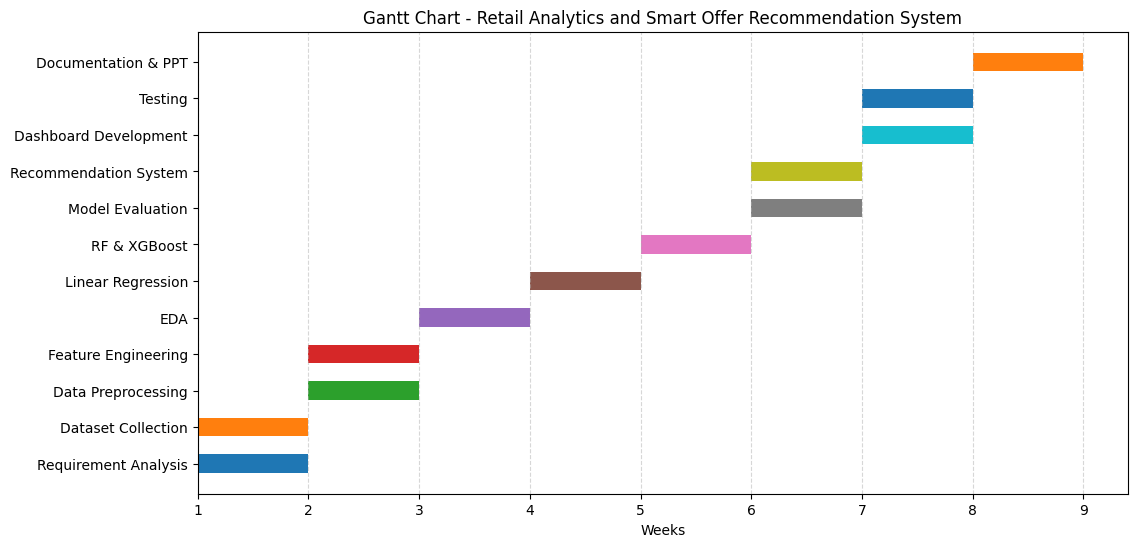

In [2]:
import matplotlib.pyplot as plt

tasks = [
    "Requirement Analysis",
    "Dataset Collection",
    "Data Preprocessing",
    "Feature Engineering",
    "EDA",
    "Linear Regression",
    "RF & XGBoost",
    "Model Evaluation",
    "Recommendation System",
    "Dashboard Development",
    "Testing",
    "Documentation & PPT"
]

start = [1, 1, 2, 2, 3, 4, 5, 6, 6, 7, 7, 8]
duration = [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

plt.figure(figsize=(12,6))

for i in range(len(tasks)):
    plt.barh(
        tasks[i],
        duration[i],
        left=start[i],
        height=0.5
    )

plt.xlabel("Weeks")
plt.title(
    "Gantt Chart - Retail Analytics and Smart Offer Recommendation System"
)

plt.xticks(range(1,10))
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()